## 1. IMPORTATIONS DES LIBRAIRIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import joblib

## 2. CHARGEMENT et EDA INITIAL (Analyse/Préparation des Données)


### Chargement des données :

In [2]:
df = pd.read_csv('../data/data.csv')


In [3]:
df.head(30)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


### Exploration des données :

In [4]:
# Affichage de la forme du DataFrame
df.shape

(1470, 35)

In [5]:
# Inspection générale (types et valeurs manquantes)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [45]:
df.isnull().sum().sum()

0

In [7]:
#Statistiques descriptives des colonnes numériques
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [8]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [48]:
df.duplicated().sum()

0

In [9]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

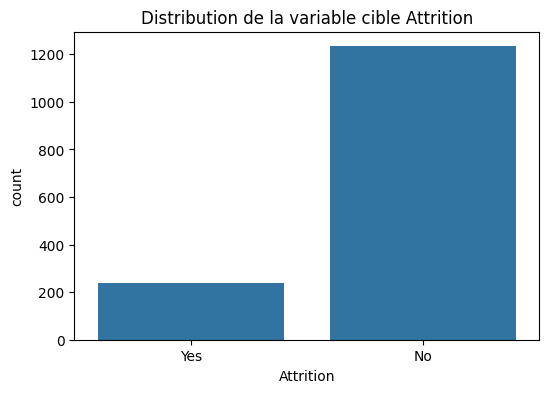

In [10]:
# import matplotlib.pyplot as plt   
# import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='Attrition', data=df)
plt.title('Distribution de la variable cible Attrition')
plt.show()

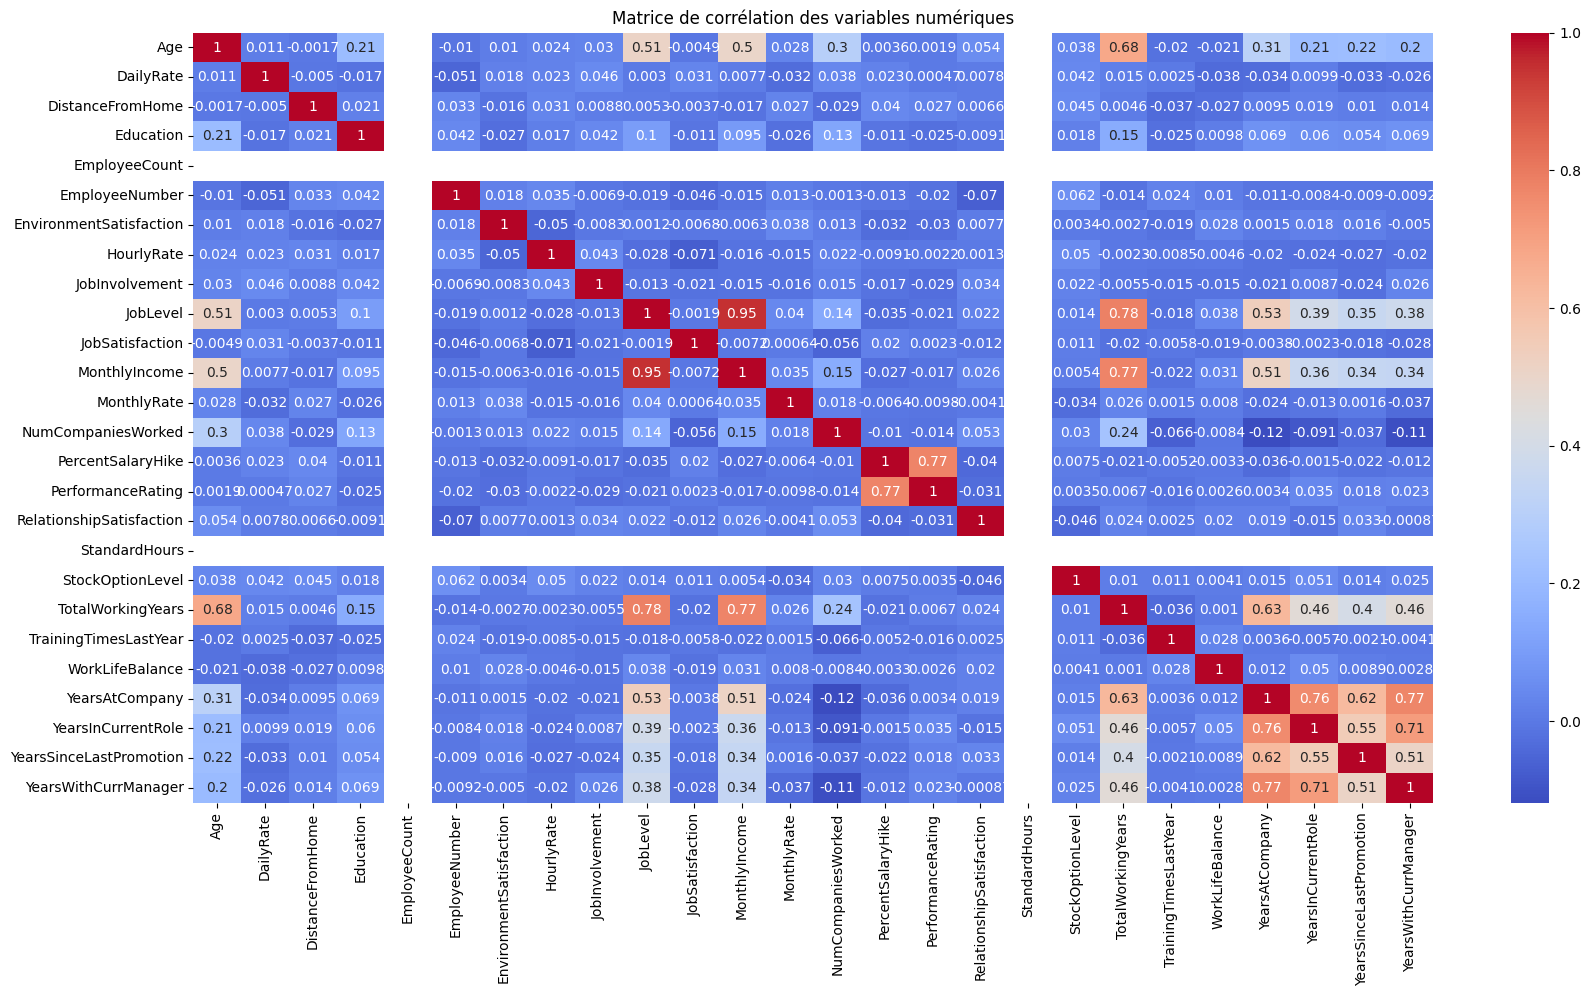

In [11]:
# Matrice de corrélation (pour les variables numériques)
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(20,10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Matrice de corrélation des variables numériques')
plt.show()

In [12]:
# Nous allons supprimer les colonnes qui ne sont pas des features pertinentes pour la prédiction.
# Par exemple, EmployeeNumber est un identifiant unique, EmployeeCount est constant, Over18 est constant, StandardHours est constant.
# Ces colonnes n'apportent aucune information pour la prédiction.

cols_to_drop = ['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours']
data = df.drop(columns=cols_to_drop)

In [13]:
# Vérifions les colonnes restantes
data.columns.tolist()

['Age',
 'Attrition',
 'BusinessTravel',
 'DailyRate',
 'Department',
 'DistanceFromHome',
 'Education',
 'EducationField',
 'EnvironmentSatisfaction',
 'Gender',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobRole',
 'JobSatisfaction',
 'MaritalStatus',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'OverTime',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

## 3. PRÉPROCESSING : Séparation des variables et transformation de la cible

In [14]:

# Séparation des features et de la cible
X = data.drop('Attrition', axis=1)
y = data['Attrition']

In [15]:
# Encodage de la cible : Yes -> 1, No -> 0
y = y.map({'Yes': 1, 'No': 0})


In [16]:
# Identification des colonnes catégorielles et numériques
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

In [17]:
# Colonnes catégorielles
categorical_cols

['BusinessTravel',
 'Department',
 'EducationField',
 'Gender',
 'JobRole',
 'MaritalStatus',
 'OverTime']

In [18]:
# Colonnes numériques :
numeric_cols

['Age',
 'DailyRate',
 'DistanceFromHome',
 'Education',
 'EnvironmentSatisfaction',
 'HourlyRate',
 'JobInvolvement',
 'JobLevel',
 'JobSatisfaction',
 'MonthlyIncome',
 'MonthlyRate',
 'NumCompaniesWorked',
 'PercentSalaryHike',
 'PerformanceRating',
 'RelationshipSatisfaction',
 'StockOptionLevel',
 'TotalWorkingYears',
 'TrainingTimesLastYear',
 'WorkLifeBalance',
 'YearsAtCompany',
 'YearsInCurrentRole',
 'YearsSinceLastPromotion',
 'YearsWithCurrManager']

In [19]:
# Séparation en ensemble d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# Le paramètre 'stratify=y' assure que la proportion de 'Yes' (départs) est la même dans les ensembles train et test


### Explication du concept : Stratified Train/Test Split est crucial pour les classes déséquilibrées (ce qui est souvent le cas pour le churn).
#### On doit entraîner le modèle sur une partie des données (train) et l'évaluer sur des données qu'il n'a jamais vues (test).

In [20]:
# Taille de l'ensemble d'entraînement
X_train.shape


(1176, 30)

In [21]:
# Taille de l'ensemble d'entraînement
X_test.shape

(294, 30)

## 4. CONSTRUCTION DU PIPELINE DE PRÉPROCESSING

In [22]:
# Pipeline pour les variables numériques (Normalisation/Standardisation)
numerical_pipeline = Pipeline([
    ('scaler', StandardScaler()) # StandardScaler : Centre les données à moyenne 0 et écart-type 1. Essentiel pour la Régression Logistique.
])

In [23]:
# Pipeline pour les variables catégorielles (Encodage catégoriel)
categorical_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # OneHotEncoder : Transforme les catégories (ex: 'Male', 'Female') en colonnes binaires (0 ou 1). Crucial pour les modèles mathématiques.
])

In [24]:
# Combinaison des pipelines
# Le ColumnTransformer applique des transformations différentes à différents types de colonnes.
# Pour les colonnes catégorielles : OneHotEncoder
# Pour les colonnes numériques : StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numeric_cols),
        ('cat', categorical_pipeline, categorical_cols)
    ])

## Création d'un pipeline qui inclut le preprocessing et le modèle
## Nous allons tester deux modèles : Régression Logistique et Random Forest

#### Explication du concept : Un Pipeline encapsule toutes les étapes (nettoyage, transformation, modèle) pour garantir
#### que le préprocessing appliqué aux données d'entraînement est rigoureusement le même que celui appliqué
#### aux nouvelles données de production. C'est la clé de la "reproductibilité" demandée.

## 5. ENTRAÎNEMENT & ÉVALUATION

### Modèle 1 : Régression Logistique (Simple, rapide, interprétable)

In [25]:
# Pipeline pour la régression logistique
logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])

In [26]:
logreg_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'DailyRate',
                                                   'DistanceFromHome',
                                                   'Education',
                                                   'EnvironmentSatisfaction',
                                                   'HourlyRate',
                                                   'JobInvolvement', 'JobLevel',
                                                   'JobSatisfaction',
                                                   'MonthlyIncome',
                                                   'MonthlyRate',
                                                   'NumCompaniesWorked',
                                                   'PercentSalaryHike',
                                                   'PerformanceRating',
                                                   'Relati...
                                                   'TrainingTimesLastYear',
                                                   'WorkLifeBalance',
                                                   'YearsAtCompany',
                                                   'YearsInCurrentRole',
                                                   'YearsSinceLastPromotion',
                                                   'YearsWithCurrManager']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['BusinessTravel',
                                                   'Department',
                                                   'EducationField', 'Gender',
                                                   'JobRole', 'MaritalStatus',
                                                   'OverTime'])])),
                ('classifier', LogisticRegression(random_state=42))])

In [27]:
y_pred_logreg = logreg_pipeline.predict(X_test)
y_proba_logreg = logreg_pipeline.predict_proba(X_test)[:, 1] # On veut la probabilité de la classe 1 ('Yes')

In [28]:
#Évaluation Régression Logistique
# Rapport de Classification
classification_report(y_test, y_pred_logreg)



'              precision    recall  f1-score   support\n\n           0       0.88      0.96      0.92       247\n           1       0.62      0.34      0.44        47\n\n    accuracy                           0.86       294\n   macro avg       0.75      0.65      0.68       294\nweighted avg       0.84      0.86      0.84       294\n'

In [29]:
# AUC-ROC :
roc_auc_score(y_test, y_proba_logreg)

0.8117839607201308

### Modèle 2 : Random Forest Classifier (Plus performant, moins sensible à l'échelle des données)

In [30]:

# Pipeline pour le Random Forest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [31]:
# Optimisation (GridSearchCV)
param_grid = {
    'classifier__n_estimators': [100, 200], # Nombre d'arbres
    'classifier__max_depth': [5, 10],      # Profondeur maximale
}

In [32]:
grid_search = GridSearchCV(rf_pipeline, param_grid, cv=3, scoring='roc_auc', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 4 candidates, totalling 12 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'DailyRate',
                                                                          'DistanceFromHome',
                                                                          'Education',
                                                                          'EnvironmentSatisfaction',
                                                                          'HourlyRate',
                                                                          'JobInvolvement',
                                                                          'JobLevel',
                                                                          'JobSatisfaction',
                                                                          'MonthlyIncome',
                                                                          'MonthlyRate',
                                                                          'NumCompaniesWorked',
                                                                          'PercentSalaryHike'...
                                                                        ('cat',
                                                                         Pipeline(steps=[('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['BusinessTravel',
                                                                          'Department',
                                                                          'EducationField',
                                                                          'Gender',
                                                                          'JobRole',
                                                                          'MaritalStatus',
                                                                          'OverTime'])])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [5, 10],
                         'classifier__n_estimators': [100, 200]},
             scoring='roc_auc', verbose=1)

In [33]:
best_rf_model = grid_search.best_estimator_
y_pred_rf = best_rf_model.predict(X_test)
y_proba_rf = best_rf_model.predict_proba(X_test)[:, 1]

In [34]:
#Entraînement du Random Forest
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'DailyRate',
                                                   'DistanceFromHome',
                                                   'Education',
                                                   'EnvironmentSatisfaction',
                                                   'HourlyRate',
                                                   'JobInvolvement', 'JobLevel',
                                                   'JobSatisfaction',
                                                   'MonthlyIncome',
                                                   'MonthlyRate',
                                                   'NumCompaniesWorked',
                                                   'PercentSalaryHike',
                                                   'PerformanceRating',
                                                   'Relati...
                                                   'TrainingTimesLastYear',
                                                   'WorkLifeBalance',
                                                   'YearsAtCompany',
                                                   'YearsInCurrentRole',
                                                   'YearsSinceLastPromotion',
                                                   'YearsWithCurrManager']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['BusinessTravel',
                                                   'Department',
                                                   'EducationField', 'Gender',
                                                   'JobRole', 'MaritalStatus',
                                                   'OverTime'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [35]:
# Évaluation Random Forest (Optimisé)
# Meilleurs Hyperparamètres :
grid_search.best_params_


{'classifier__max_depth': 10, 'classifier__n_estimators': 200}

In [36]:
#Rapport de Classification :
classification_report(y_test, y_pred_rf)

'              precision    recall  f1-score   support\n\n           0       0.85      0.98      0.91       247\n           1       0.50      0.13      0.20        47\n\n    accuracy                           0.84       294\n   macro avg       0.68      0.55      0.56       294\nweighted avg       0.80      0.84      0.80       294\n'

In [37]:
#Matrice de Confusion :
confusion_matrix(y_test, y_pred_rf)

array([[241,   6],
       [ 41,   6]], dtype=int64)

In [38]:
# AUC-ROC :
roc_auc_score(y_test, y_proba_rf)

0.7991213713498148

In [39]:
# Évaluation des modèles
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:,1]
    
    print(f"\n=== Évaluation de {model_name} ===")
    print("Matrice de confusion :")
    print(confusion_matrix(y_test, y_pred))
    print("\nRapport de classification :")
    print(classification_report(y_test, y_pred))
    
    # Calcul de l'AUC-ROC
    auc = roc_auc_score(y_test, y_pred_proba)
    print(f"AUC-ROC : {auc:.4f}")
    
    # Courbe ROC
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc:.2f})')
    
    return auc



=== Évaluation de Régression Logistique ===
Matrice de confusion :
[[237  10]
 [ 31  16]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294

AUC-ROC : 0.8118

=== Évaluation de Random Forest ===
Matrice de confusion :
[[243   4]
 [ 40   7]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.86      0.98      0.92       247
           1       0.64      0.15      0.24        47

    accuracy                           0.85       294
   macro avg       0.75      0.57      0.58       294
weighted avg       0.82      0.85      0.81       294

AUC-ROC : 0.7870


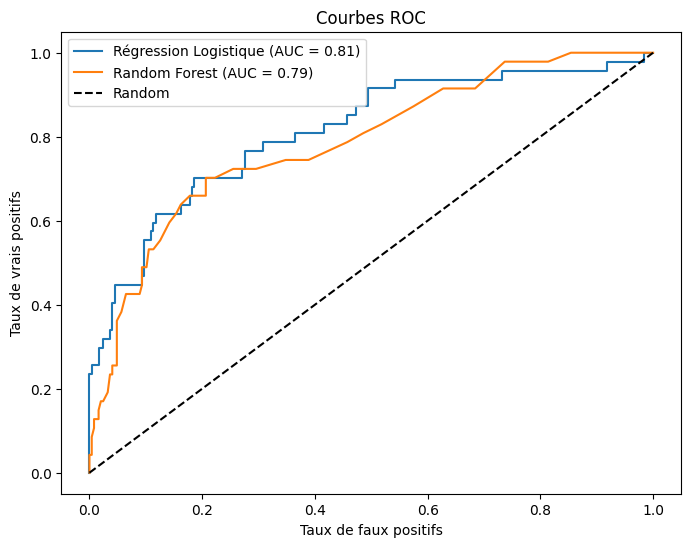

In [40]:
# Évaluation des deux modèles
plt.figure(figsize=(8,6))
auc_logreg = evaluate_model(logreg_pipeline, X_test, y_test, "Régression Logistique")
auc_rf = evaluate_model(rf_pipeline, X_test, y_test, "Random Forest")

plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbes ROC')
plt.legend()
plt.show()

In [41]:
# Optimisation des hyperparamètres pour le Random Forest
# Définition de la grille d'hyperparamètres
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2]
}


In [42]:
grid_search = GridSearchCV(rf_pipeline, param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'DailyRate',
                                                                          'DistanceFromHome',
                                                                          'Education',
                                                                          'EnvironmentSatisfaction',
                                                                          'HourlyRate',
                                                                          'JobInvolvement',
                                                                          'JobLevel',
                                                                          'JobSatisfaction',
                                                                          'MonthlyIncome',
                                                                          'MonthlyRate',
                                                                          'NumCompaniesWorked',
                                                                          'PercentSalaryHike'...
                                                                         ['BusinessTravel',
                                                                          'Department',
                                                                          'EducationField',
                                                                          'Gender',
                                                                          'JobRole',
                                                                          'MaritalStatus',
                                                                          'OverTime'])])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [10, 20, None],
                         'classifier__min_samples_leaf': [1, 2],
                         'classifier__min_samples_split': [2, 5],
                         'classifier__n_estimators': [100, 200]},
             scoring='roc_auc', verbose=1)

## Choix du modèle :

## 6. SAUVEGARDE DU MEILLEUR MODÈLE

In [44]:
# on sauvegarde le pipeline complet, qui contient le préprocessing et le modèle.
model_path = '../ml_model/full_pipeline.pkl'
joblib.dump(best_rf_model, model_path)

['../ml_model/full_pipeline.pkl']